<a href="https://colab.research.google.com/github/samuelperez1232/prospectiva_analitica_datos/blob/main/tendencia_central_y_dispersion_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Semana 3 clase 3
## **CASO DE ESTUDIO**

EVERGREEN es un conglomerado taiwanés que opera en diversas industrias
a nivel global. Su principal empresa, Evergreen Marine Corporation, se
especializa en el transporte marítimo de contenedores, gestionando una flota
de más de 150 buques y ofreciendo servicios en 240 puertos alrededor del
mundo.
 La empresa, está interesada en desarrollar un sistema por
adaptación y aprendizaje que le permita proyectar desde la gestión
de sus riesgos el valor potencial de captura de gases de efecto
invernadero.



Las barreras que serán utilizadas para este proceso son las siguientes:
- Frecuencia: indica el número de contenedores semanales que la empresa deja en tierra (numero/semana)

- Severidad: Es el costo promedio del tratamiento de cada contenedor (USD/contenedor).

- Distribución perdidas: Es el producto entre la frecuencia y la severidad. Esta distribución agrupa los parámetros de riesgo.





# **CLASE #4 Semana 4**
##Método medidas tendencia y dispersión:

Se procederá con la construcción de un método que nos permita, de forma recurrente calcular las medidas de tenencia central y dispersión de cualquier variable que se tenga dentro del espacio de trabajo.

0. Instalación y carga de librerias de trabajo

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# para cargar los datos automaticamente
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. se procede con la carga de los datos de trabajo

XDB= Excel database
LDA= lost distribution
SEV= severidad

In [5]:
nxl="/content/drive/MyDrive/EAFIT/LINEA_DE_ENFASIS/Prospectiva/ejercicio #2_semana3/1. RiesgoOperacional_EVERGREEEN.xlsx" # Define la ruta del archivo Excel en Google Drive
XDB=pd.read_excel(nxl,sheet_name=0) # Carga el archivo Excel en un DataFrame de pandas, tomando la primera hoja (índice 0)
# Muestra el DataFrame 'XDB' como una tabla formateada
display(XDB)

# Muestra la estructura del DataFrame, incluyendo tipos de datos y valores no nulos
print(XDB.info())

,Semana,Transacción Semanales,Valor Transado (MUSD),Eventos (Semana),Severidad (KUSD),Riesgo,LDA,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,intervalo,Limite inferior,limite superior,ND,fi,marca clase
0,1,44,27.145501,4,2.867141,Riesgo de Error en Reportes No Críticos,11.468562,NaN,NaN,NaN,minimo,2.599197,1.0,2.599197,308.929450,2209.0,0.787803,155.764324
1,2,194,68.447342,20,6.420941,Riesgo Regulatorio,128.418827,NaN,NaN,NaN,maximo,3065.901730,2.0,308.929450,615.259703,356.0,0.126961,462.094577
2,3,217,20.111928,22,2.174181,Riesgo de Error en Reportes No Críticos,47.831980,NaN,NaN,NaN,rango,3063.302533,3.0,615.259703,921.589957,116.0,0.041369,768.424830
3,4,278,60.008094,28,5.816689,Riesgo Logístico y de Cadena de Suministro,162.867297,NaN,NaN,NaN,NI,10.000000,4.0,921.589957,1227.920210,46.0,0.016405,1074.755083
4,5,286,63.007004,31,6.375786,Riesgo Regulatorio,197.649353,NaN,NaN,NaN,tam intervalo,306.330253,5.0,1227.920210,1534.250463,27.0,0.009629,1381.085337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2799,2800,39,23.886707,4,2.613396,Riesgo de Error en Reportes No Críticos,10.453583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2800,2801,319,40.392800,29,3.666040,Riesgo Administrativo Menor,106.315153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2801,2802,495,19.572457,53,1.905119,Riesgo de Equipamiento Secundario,100.971315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2802,2803,197,14.077296,19,1.329140,Riesgo de Equipamiento Secundario,25.253669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2804 entries, 0 to 2803
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Semana                 2804 non-null   int64  
 1   Transacción Semanales  2804 non-null   int64  
 2   Valor Transado (MUSD)  2804 non-null   float64
 3   Eventos (Semana)       2804 non-null   int64  
 4   Severidad (KUSD)       2804 non-null   float64
 5   Riesgo                 2711 non-null   object 
 6   LDA                    2804 non-null   float64
 7   Unnamed: 7             0 non-null      float64
 8   Unnamed: 8             0 non-null      float64
 9   Unnamed: 9             0 non-null      float64
 10  Unnamed: 10            12 non-null     object 
 11  Unnamed: 11            8 non-null      float64
 12  intervalo              10 non-null     float64
 13  Limite inferior        10 non-null     float64
 14  limite superior        10 non-null     float64
 15  ND  

2. se procede con la construcción del histograma de frecuencias

este es el histograma para la frecuencia
la medida de la frecuencia es: 23.900499286733236
la varianza de la frecuencia es: 209.53778862375123
la desviacion estandar de la frecuencia es: 14.475420153617346
el coeficiente de asimetria de la frecuencia es: 0.7228833909265031
el coeficiente de curtosis de la frecuencia es: 2.816365104876639


,LI,LS,ND,fi,MC
0,4.0,12.2,784.0,0.279601,8.1
1,12.2,20.4,575.0,0.205064,16.3
2,20.4,28.6,492.0,0.175464,24.5
3,28.6,36.8,369.0,0.131598,32.7
4,36.8,45.0,295.0,0.105207,40.9
5,45.0,53.2,216.0,0.077033,49.1
6,53.2,61.4,46.0,0.016405,57.3
7,61.4,69.6,18.0,0.006419,65.5
8,69.6,77.8,6.0,0.002140,73.7
9,77.8,86.0,3.0,0.001070,81.9


este es el histograma para la severidad
la medida de la severidad es: 10.35036444248319
la varianza de la severidad es: 110.04833672232647
la desviacion estandar de la severidad es: 10.490392591429858
el coeficiente de asimetria de la severidad es: 2.969908751537144
el coeficiente de curtosis de la severidad es: 14.342791576696708


,LI,LS,ND,fi,MC
0,0.396153,9.854509,1942.0,0.692582,5.125331
1,9.854509,19.312865,534.0,0.190442,14.583687
2,19.312865,28.771222,153.0,0.054565,24.042044
3,28.771222,38.229578,71.0,0.025321,33.500400
4,38.229578,47.687934,60.0,0.021398,42.958756
5,47.687934,57.146291,26.0,0.009272,52.417113
6,57.146291,66.604647,10.0,0.003566,61.875469
7,66.604647,76.063003,2.0,0.000713,71.333825
8,76.063003,85.521360,2.0,0.000713,80.792181
9,85.521360,94.979716,4.0,0.001427,90.250538


este es el histograma para la distribuccion LDA
la medida de la distribucion de perdidas es: 279.6510949925361
la varianza de la distribucion de perdidas es: 102317.97222569383
la desviacion estandar de la distribucion de perdidas es: 319.87180592495775
el coeficiente de la distribuccion de perdidas es: 3.792311305904773
el coeficiente de curtosis de la distribuccion de las perdidas es: 20.131316115151854


,LI,LS,ND,fi,MC
0,2.599197,308.929450,2209.0,0.787803,155.764324
1,308.929450,615.259703,356.0,0.126961,462.094577
2,615.259703,921.589957,116.0,0.041369,768.424830
3,921.589957,1227.920210,46.0,0.016405,1074.755083
4,1227.920210,1534.250463,27.0,0.009629,1381.085337
5,1534.250463,1840.580717,18.0,0.006419,1687.415590
6,1840.580717,2146.910970,20.0,0.007133,1993.745843
7,2146.910970,2453.241223,7.0,0.002496,2300.076097
8,2453.241223,2759.571476,4.0,0.001427,2606.406350
9,2759.571476,3065.901730,1.0,0.000357,2912.736603


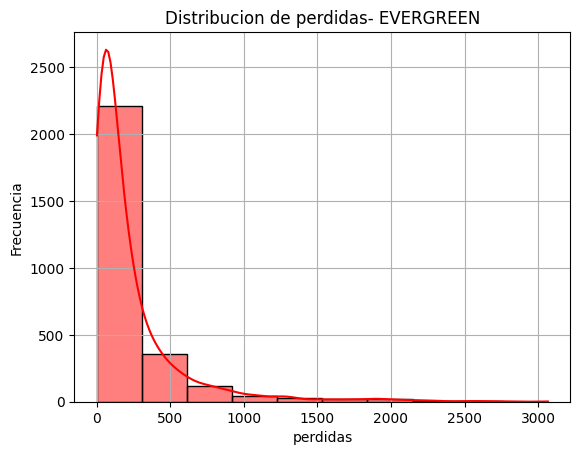

In [37]:
Freq=XDB.iloc[:,3] # Extrae la cuarta columna (índice 3) del DataFrame 'XDB' para la 'Frecuencia'
Sev=XDB.iloc[:,4] # Extrae la quinta columna (índice 4) del DataFrame 'XDB' para la 'Severidad'
LDA_Evergreen=Freq*Sev # Calcula la 'Distribución de Pérdidas' multiplicando Frecuencia por Severidad



print("este es el histograma para la frecuencia")
dff,uf,varf,sigf,casf,curtf=MedidasDTC(Freq,10)
print("la medida de la frecuencia es:",uf)
print("la varianza de la frecuencia es:",varf)
print("la desviacion estandar de la frecuencia es:",sigf)
print("el coeficiente de asimetria de la frecuencia es:",casf)
print("el coeficiente de curtosis de la frecuencia es:",curtf)
display(dff)


print("este es el histograma para la severidad")
dfs,us,vars,desvs,cass,curts=MedidasDTC(Sev,10) # Se añadió 'curts' para recibir el sexto valor devuelto
print("la medida de la severidad es:",us)
print("la varianza de la severidad es:",vars)
print("la desviacion estandar de la severidad es:",desvs)
print("el coeficiente de asimetria de la severidad es:",cass)
print("el coeficiente de curtosis de la severidad es:",curts) # Se añadió la impresión de 'curts'
display(dfs)

print("este es el histograma para la distribuccion LDA")
# Corregido: Se cambió LDA por LDA_Evergreen ya que LDA no estaba definido.
dflda,ulda,varlda,desvlda,caslda,curtlda=MedidasDTC(LDA_Evergreen,10)
print("la medida de la distribucion de perdidas es:",ulda)
print("la varianza de la distribucion de perdidas es:",varlda)
print("la desviacion estandar de la distribucion de perdidas es:",desvlda)
print("el coeficiente de la distribuccion de perdidas es:",caslda)
print("el coeficiente de curtosis de la distribuccion de las perdidas es:",curtlda)
display(dflda)

plt.figure() # Crea una nueva figura para el gráfico
sns.histplot(LDA_Evergreen,color='red', bins=10, kde=True) # Genera un histograma de la 'Distribución de Pérdidas' (LDA)
plt.title('Distribucion de perdidas- EVERGREEN') # Establece el título del gráfico
plt.xlabel('perdidas') # Etiqueta el eje X como 'pérdidas'
plt.ylabel('Frecuencia') # Etiqueta el eje Y como 'Frecuencia'
plt.grid() # Agrega una cuadrícula al gráfico
plt.show() # Muestra el gráfico generado

## análsis de resultados

De acuerdo con lo anterior, podemos observar en general que las variables frecuencia (0.7228833909265031), severidad (2.969908751537144), y distribuccion de las perdidas (3.792311305904773) alcanzaron con eventos de asimetría general positivos. Esto indica que las pérdidas tienden a ubicarse de forma particular por debajo de la medida de las pérdidas. Se destaca que la distribución de las pérdidas tuvo en general el coeficiente de asimetría, lo que indica que las pérdidas al final no tendrán impacto significativo en las finanzas de una organización. Es importante mencionar que las distribuciones generales poseen estructuras esbeltas de cola larga, como se observa en la gráfica de la distribución LDA (Distribution Approach).

In [36]:
def MedidasDTC(Xi,NI):

    # si queremos agregar el NI y tenerlo dentro del metodo la ponemos junto
    # al Xi dentro del parentesis

    #datos de salida:
    #arroja las medidas de tendencia central u (media), var (varianza),
    #desv (desviacion), cas (coeficiente de asimetria)

    # Corregido: plt.hist devuelve directamente los conteos y los bordes de los bins.
    # sns.histplot devuelve un objeto Axes que no tiene el método .get_data().
    # El parámetro kde no es aplicable a plt.hist si solo queremos los datos.
    # Corregido: Usar Xi en lugar de LDA_Evergreen para que la función sea genérica
    counts, limits=np.histogram(Xi,bins=NI) #agrupa los datos en 10 intervalos
    LI=limits[:-1] #limites inferiores del histograma
    LS=limits[1:] #limites superiores del histograma
    fi=counts/sum(counts) # frecuencia relativa (porcentaje de datos por intervalos)
    MC=(LI+LS)/2 # punto medio de cada intervalo

    df=pd.DataFrame(np.column_stack((LI,LS,counts,fi,MC)))
    df.columns=["LI","LS","ND","fi","MC"]
    #display(df)

    #1 Media - valor esperado de una perdida ( que es lo mas común que pase?)
    u=np.sum(MC*fi)

    #2 varianza: indica que tan dispersos estan los datos con respecto a la media
    varc=np.sum((MC-u)**2*fi)

    #3 desviación standar
    sigma=np.sqrt(varc)

    #5 coeficiente de asimetria
    cas=np.sum((MC-u)**3*fi)/((sigma**3))

    #6. coeficiente de curtosis (tarea)
    curt=np.sum((MC-u)**4*fi)/((sigma**4))

    return df,u,varc,sigma,cas,curt

3. Medidas de tendencia central

In [8]:
#1 Media - valor esperado de una perdida ( que es lo mas común que pase?)
u=np.sum(MC*fi)
print("Media = ",u)

#2 varianza: indica que tan dispersos estan los datos con respecto a la media
varc=np.sum((MC-u)**2*fi)
print("Varianza = ",varc)

#3 desviación standar
sigma=np.sqrt(varc)
print("Desviación estandar = ",sigma)

#4 intervalo de variación de la perdidas
# en este intervalo se encuentra el 95% de los datos (2*sigma)
# en este intervalo se encuentran el 68% de los datos (1*sigma)
print(" el limite inferior es =",u-2*sigma)
print(" el limite superior es =",u+2*sigma)

#5 coeficiente de asimetria
cas=np.sum((MC-u)**3*fi)/((sigma**3))
print("Coeficiente de asimetria = ",cas)


#6. coeficiente de curtosis (tarea)
curt=np.sum((MC-u)**4*fi)/((sigma**4))
print("Coeficiente de curtosis = ",curt)




Media =  279.6510949925361
Varianza =  102317.97222569383
Desviación estandar =  319.87180592495775
 el limite inferior es = -360.0925168573794
 el limite superior es = 919.3947068424516
Coeficiente de asimetria =  3.792311305904773
Coeficiente de curtosis =  20.131316115151854
